In [1]:
!pip install yfinance --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
data = yf.download('AAPL', start='2015-01-01', end='2025-01-01')
close_prices = data[['Close']].values
print(data.tail())

/tmp/ipykernel_684/4240988162.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download('AAPL', start='2015-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            AAPL        AAPL        AAPL        AAPL      AAPL
Date                                                                
2024-12-24  256.339783  256.349690  253.450729  253.649301  23234700
2024-12-26  257.153809  258.226044  255.773839  256.329802  27237100
2024-12-27  253.748520  256.836129  251.236749  255.972371  42355300
2024-12-30  250.382950  251.673587  248.943400  250.412732  35557500
2024-12-31  248.615784  251.455179  247.632911  250.621234  39480700


In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(close_prices)

In [4]:
WINDOW = 60

def create_sequences(dataset, window):
    X, y = [], []
    for i in range(window, len(dataset)):
        X.append(dataset[i-window:i, 0])
        y.append(dataset[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, WINDOW)
X = X.reshape(X.shape[0], X.shape[1], 1)
print('X shape:', X.shape, '| y shape:', y.shape)

X shape: (2456, 60, 1) | y shape: (2456,)


In [5]:
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]
print('Train samples:', len(X_train), '| Test samples:', len(X_test))

Train samples: 1964 | Test samples: 492


In [6]:
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(WINDOW, 1)),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [8]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0113 - val_loss: 0.0065
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0013 - val_loss: 0.0010
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0010 - val_loss: 0.0011
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 9.0149e-04 - val_loss: 0.0011
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 7.4347e-04 - val_loss: 0.0013
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 8.6249e-04 - val_loss: 0.0010
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 7.7389e-04 - val_loss: 7.7015e-04
Epoch 9/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 6.5226e-04 - val_loss: 0.0013
Epoch 10/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.9141e-04 - val_loss: 7.6594e-04
Epoch 11/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.6318e-04 - val_loss: 9.7509e-04
Epoch 12/50
56/56 ━━━━━

In [9]:
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)
actual = scaler.inverse_transform(y_test.reshape(-1, 1))

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


In [10]:
rmse = np.sqrt(mean_squared_error(actual, predictions))
mae = mean_absolute_error(actual, predictions)
print('RMSE:', rmse)
print('MAE:', mae)

RMSE: 10.734533969401385
MAE: 8.90893497311972


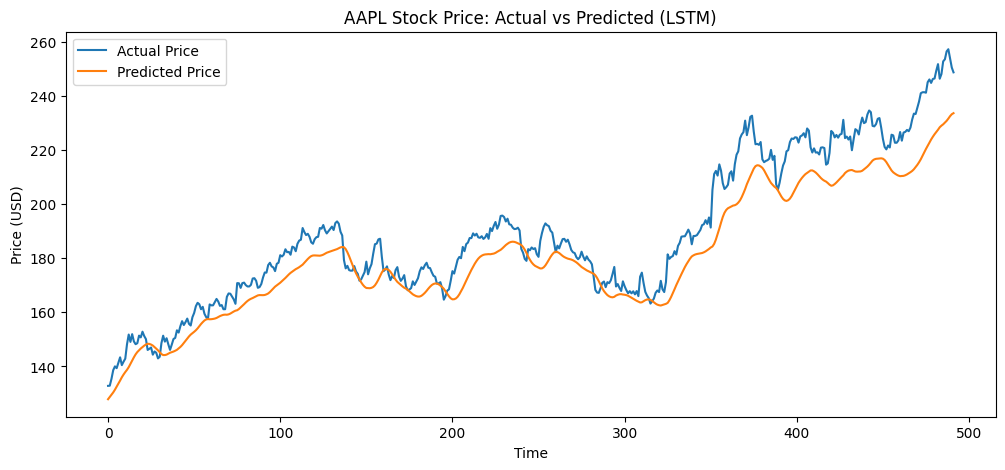

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(actual, label='Actual Price')
plt.plot(predictions, label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.title('AAPL Stock Price: Actual vs Predicted (LSTM)')
plt.legend()
plt.show()

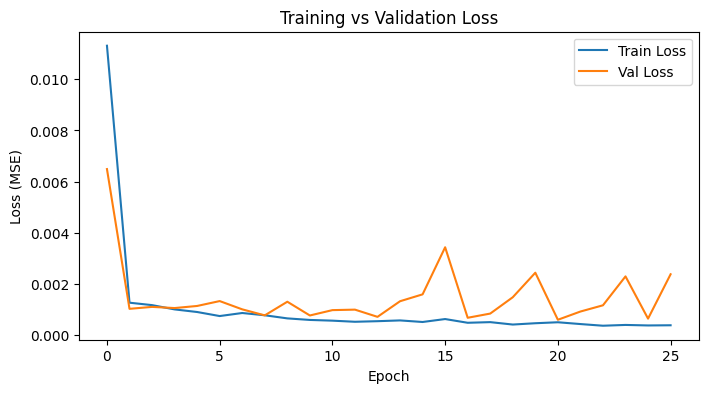

In [12]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(actual, predictions))
mae = mean_absolute_error(actual, predictions)
r2 = r2_score(actual, predictions)

# MAPE - error as a percentage, easier to interpret than raw price error
mape = np.mean(np.abs((actual - predictions) / actual)) * 100

print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'MAPE: {mape:.2f}%')   # e.g. 2.5% means predictions are off by ~2.5% on average
print(f'R² score: {r2:.4f}')  # closer to 1 = better fit; 0 = no better than predicting the mean

RMSE: 10.73
MAE: 8.91
MAPE: 4.49%
R² score: 0.8414


In [14]:
actual_direction = np.diff(actual.flatten()) > 0        # True if price went up
predicted_direction = np.diff(predictions.flatten()) > 0

directional_accuracy = np.mean(actual_direction == predicted_direction) * 100
print(f'Directional Accuracy: {directional_accuracy:.2f}%')
# 50% = no better than a coin flip. Above ~55-60% is considered decent for stock data.

Directional Accuracy: 52.75%


In [15]:
naive_predictions = actual[:-1]   # yesterday's price used as "prediction" for today
naive_actual = actual[1:]

naive_rmse = np.sqrt(mean_squared_error(naive_actual, naive_predictions))
print(f'Naive baseline RMSE: {naive_rmse:.2f}')
print(f'LSTM model RMSE:     {rmse:.2f}')

if rmse < naive_rmse:
    print('✅ Model beats the naive baseline')
else:
    print('⚠️ Model is NOT better than just guessing "no change" — needs improvement')

Naive baseline RMSE: 2.54
LSTM model RMSE:     10.73
⚠️ Model is NOT better than just guessing "no change" — needs improvement


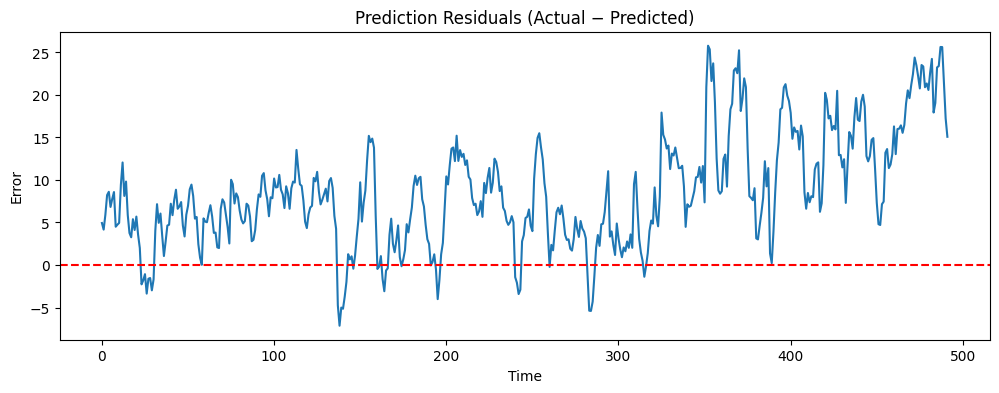

Mean residual: 8.55760352592158
Std of residuals: 6.480558728486824


In [16]:
residuals = actual.flatten() - predictions.flatten()

plt.figure(figsize=(12, 4))
plt.plot(residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Prediction Residuals (Actual − Predicted)')
plt.xlabel('Time')
plt.ylabel('Error')
plt.show()

print('Mean residual:', np.mean(residuals))   # close to 0 = no systematic bias
print('Std of residuals:', np.std(residuals))

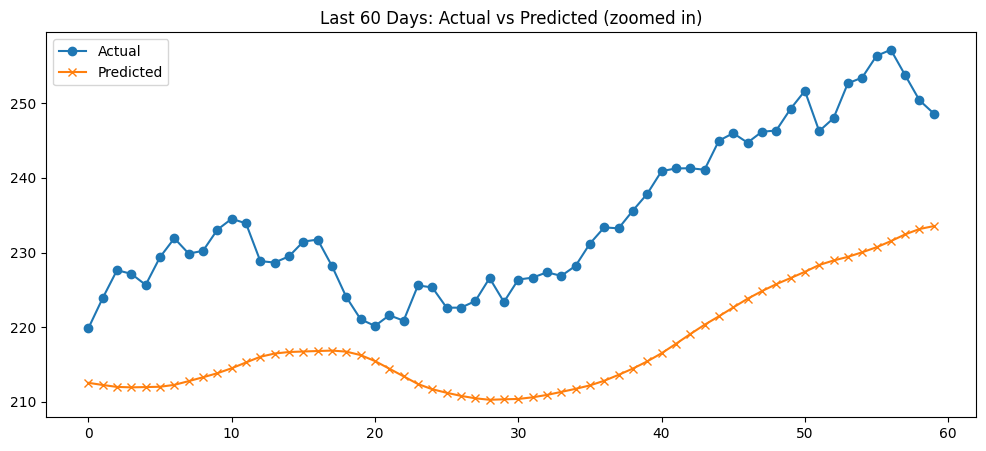

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(actual[-60:], label='Actual', marker='o')
plt.plot(predictions[-60:], label='Predicted', marker='x')
plt.title('Last 60 Days: Actual vs Predicted (zoomed in)')
plt.legend()
plt.show()